# Programming exercise 2: Time evolution and performance of diagonalization routines

Due on Monday, 27.04.2026, 20h

## Goals of the exercise

In the first exercise we calculated the eigenenergies and eigenfunction of a quantum particle in a one-dimensional potential by representing the wave function on a discrete spatial grid and using `np.eigh()` to diagonalize the Hamiltonian matrix. This time we want to use the obtained eigenfunctions to calculate the time evolution for an arbitrary initial state and compare the performance of different routines for exact diagonalization, also exploring the benefits of sparse matrices.

In [207]:
# load standard libraries

import numpy as np   # standard numerics library

import matplotlib.pyplot as plt # for making plots

import Comp_Quant_Dynam as cqd # our numerics library


### Exercise 1

Calculate the eigenfunctions of the harmonic oscillator on a grid as in programming exercise 1.
Calculate and plot the time evolution for an initial state which is an equal superposition between the lowest two eigenfunctions.
You can animate the plot by completing the code snippet below. Calculate the expectation value $\langle x \rangle$ as a function of time. What is the functional form of the result? Does it match your expectation from the analytical solution?

Hints: Read about broadcasting rules in python. `np.sum()` and matrix multiplication using `@` might be useful.

- Solve the eigenvalue problem

In [208]:
from numpy import linalg as LA   # diagonalization and more

# define the grid
L = 20
npoints = 400
dx = L/(npoints - 1)
xvals = np.linspace(-L/2,L/2,npoints)

# build the terms of the Hamiltonian
H_pot = cqd.hamiltonians.HO_potential(xvals)
H_kin = cqd.hamiltonians.H_kinetic(xvals)

H_mat = H_pot + H_kin

evals, evecs = LA.eigh(H_mat)



- Time evolution of superpositions

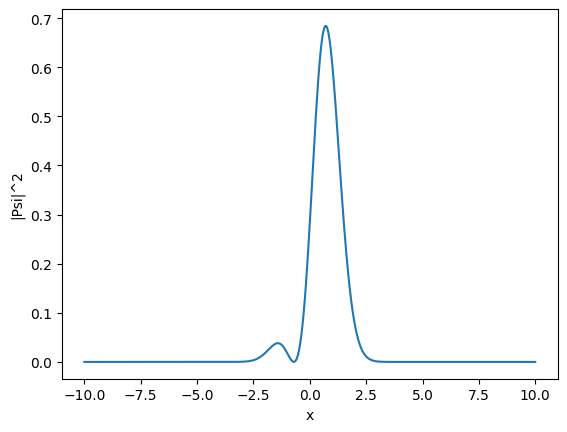

In [210]:
a = np.zeros(400)
a[0] = 1/np.sqrt(2)
a[1] = 1/np.sqrt(2)

#Define Psi(x,t) 
def psi(t):
    return np.sum(evecs * a * np.exp(-1j*evals*t), 1) #result is vector with sum for each x_i in every component
#Define the prop.density
def psi_abs_sq(t):
     return np.abs(psi(t))**2/dx
plt.plot(xvals,psi_abs_sq(0))   #example for t=0
plt.xlabel("x")
plt.ylabel("|Psi|^2")
plt.show()

- Animate the solutions

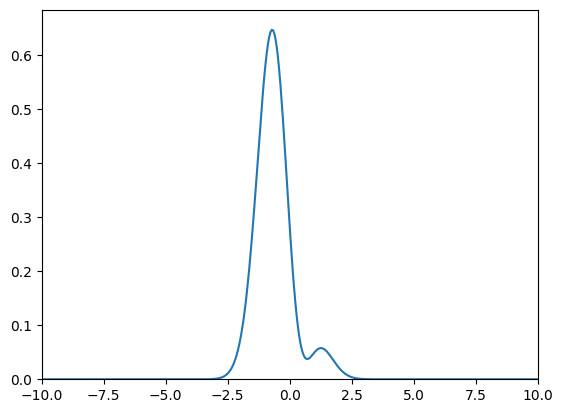

In [ ]:
from matplotlib import animation
from IPython.display import HTML

fig, ax = plt.subplots()
# add more axis specifications here, e.g. axis limits
ax.set_xlim(xvals.min(), xvals.max())
ax.set_ylim(0, np.max(psi_abs_sq(0))*1.1)
line, = ax.plot([],[])
def animate(t):
    y = psi_abs_sq(t)
    line.set_data(xvals, y)
    return (line,)

anim = animation.FuncAnimation(fig, animate,
                               frames=np.arange(0,10,0.1), # t-values
                               interval=50, # wait time before displaying new frame in ms
                               blit=True)

HTML(anim.to_jshtml())

- Compute the expectation value of x

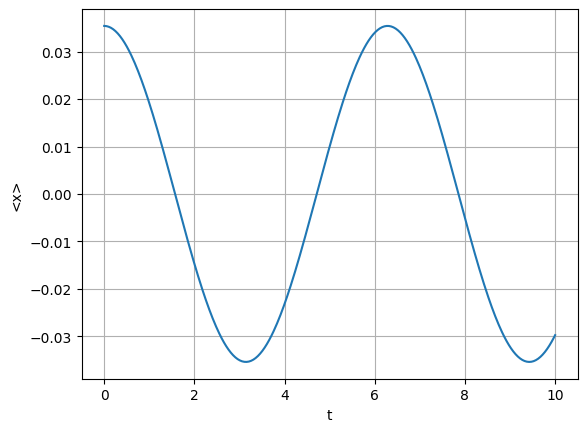

In [124]:
tvals = np.linspace(0,10,400) #time interval

#expectation value <x>(t)
def expval(x,t):
    return np.sum(np.conj(psi(t))*x*psi(t))*dx        # needs full interval xvals as input to compute expectation value for 
                                                      # for one specific time t

#save expvalue for different times
exval_array = []
for i in range(len(tvals)):
     exval_array.append(expval(xvals,tvals[i]))

#plot of expectation value over time
plt.plot(tvals,np.real(exval_array))
plt.grid()
plt.xlabel("t")
plt.ylabel("<x>")
plt.show()
#cos(t) behavior

### Exercise 2

Calculate the time evolution for arbitrary initial states by decomposing them into a superposition of eigenstates. Test your implementation for a coherent state, i.e. a Gaussian state that is shifted by $x_0$:
$$
\psi_0(x) = \frac{1}{\pi^{1/4}}e^{-(x-x_0)^2/2}
$$
Again, animate the resulting dynamics and also calculate the expectation value of x as a function of time. Describe and interpret your observations.

**Optional**: Play with other initial conditions and other potentials. For example take the double well potential from problem sheet 1 and initialize the system in a state localized on one side. What happens? How do the dynamics depend on the barrier height, i.e. on $\lambda$? Also instructive: Build up the coherent state by taking into account more and more of the eigenstates in the initial superposition and observe what happens to the time evolution.

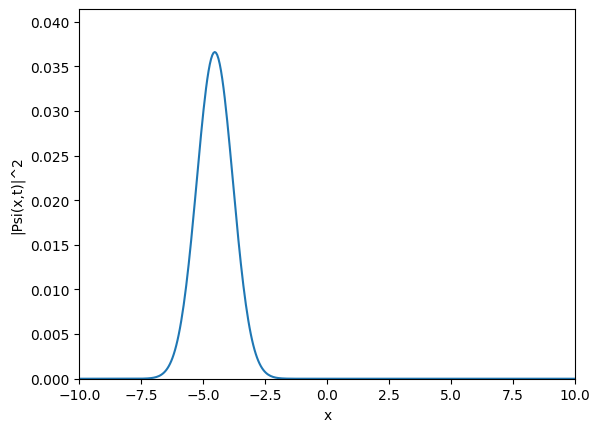

In [162]:
from matplotlib import animation
from IPython.display import HTML

def coh_stat(x,x_0):
    return 1/(np.sqrt(np.pi)**0.25)*np.exp(-(x-x_0)**2/2)  #gives functionvalue as vector for each x_i (if x=xvals)

#Initial state psi_0 (x,t)
psi_0 = coh_stat(xvals,5)

# Analytical: a_n = integral phi * psi_0 --> discrete: sum over them
def a(psi_0):
   return np.conj(evecs).T @ psi_0 *dx

#time evolution
##Final general psi(x,t) 
def psi_gen(t):
    return np.sum(evecs * a(psi_0) * np.exp(-1j*evals*t),1)
#general prop.density
def psi_abs_sq_gen(t):
    return np.abs(psi_gen(t))**2/dx

fig, ax = plt.subplots()
ax.set_xlabel("x")
ax.set_ylabel("|Psi(x,t)|^2")
ax.set_xlim(xvals.min(), xvals.max())
ax.set_ylim(0, np.max(psi_abs_sq_gen(0))*1.1)
line, = ax.plot([],[])
def animate(t):
    y = psi_abs_sq_gen(t)
    line.set_data(xvals, y)
    return (line,)

anim = animation.FuncAnimation(fig, animate,
                               frames=np.arange(0,10,0.1), # t-values
                               interval=50, # wait time before displaying new frame in ms
                               blit=True)

HTML(anim.to_jshtml())


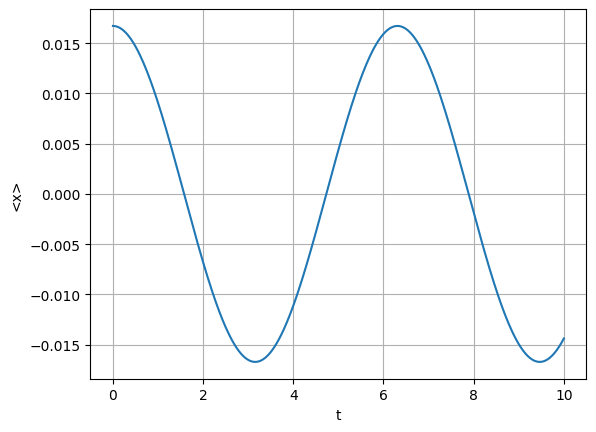

In [161]:
#expectation value
def expval_gen(x,t):
    return np.sum(np.conj(psi_gen(t))*x*psi_gen(t))*dx

exval_array = []
for i in range(len(tvals)):
     exval_array.append(expval_gen(xvals,tvals[i]))

#plot of expectation value over time
plt.plot(tvals,np.real(exval_array))
plt.grid()
plt.xlabel("t")
plt.ylabel("<x>")
plt.show()

### Exercise 3

How does the runtime scale with the basis size (number of grid points)? Increase the number of gridpoints from 101 to 1601 in steps of 100 and record the time needed for the exact diagonalization. Plot the runtime as a function of basis size on a double logarithmic scale. Also try out the routine `scipy.linalg.eigh_tridiagonal()` and compare its runtime to `np.eigh()`.

The purpose of this exercise is to sensibilize you that using routines that take into account as much information about the problem to be solved can be a huge advantage in terms of computation time.
The outcome may vary depending on the machine you are using. You are encouraged to explore the documentation of the respective functions and find out what kind of routines they are using underneath.

**Hints**: You can e.g. use the "time" module you can measure the time it takes to do the diagonalization (see code snippet below).

In [ ]:
...
ti = time.time()
#statement I want to time
tf = time.time()
runtimes.append(tf-ti)
...

- Runtime analysis

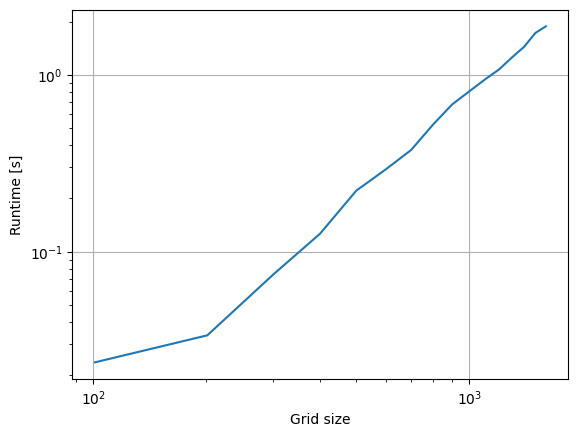

In [185]:
from numpy import linalg as LA   # diagonalization and more
import time
# define the grid
L = 20
Nruns = 10
grid_size = list(range(101,1701,100))
Ngrid = len(grid_size)
runtimes = np.zeros((Nruns,Ngrid))
for i in range(Nruns):                                  # multiple runs       
    for j, npoints in enumerate(grid_size):   # computing diagonalization and measuring time
        ti = time.time()
        dx = L/(npoints - 1)
        xvals = np.linspace(-L/2,L/2,npoints)
        H_pot = cqd.hamiltonians.HO_potential(xvals)
        H_kin = cqd.hamiltonians.H_kinetic(xvals)
        H_mat = H_pot + H_kin
        evals, evecs = LA.eigh(H_mat)
        #statement I want to time
        tf = time.time()
        runtimes[i,j] = tf-ti
runtimes_av = np.mean(runtimes,axis=0)
plt.plot(grid_size,runtimes_av)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Grid size")
plt.ylabel("Runtime [s]")
plt.grid()
plt.show()


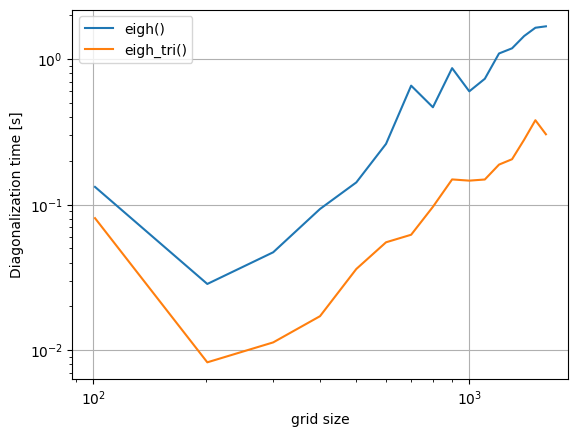

In [205]:
#Comparison of eigh()and eigh_tridiagonal() runtime
import scipy as sc
L = 20
grid_len = []
runtime_eigh = []
runtime_tri = []
for npoints in range(101,1701,100):
    dx = L/(npoints - 1)
    xvals = np.linspace(-L/2,L/2,npoints)

    #eigh()
    t_0_eigh = time.time()
    H_pot = cqd.hamiltonians.HO_potential(xvals)
    H_kin = cqd.hamiltonians.H_kinetic(xvals)
    H_mat = H_pot + H_kin
    evals, evecs = LA.eigh(H_mat)
    t_1_eigh = time.time()
    runtime_eigh.append(t_1_eigh - t_0_eigh)
    #eigh_tridiagonal
    t_0_tri = time.time()
    d = np.diag(H_mat)
    e = np.diag(H_mat,1)
    evals_tri , evecs_tri = sc.linalg.eigh_tridiagonal(d,e)
    t_1_tri = time.time()
    runtime_tri.append(t_1_tri - t_0_tri)
    grid_len.append(npoints)

plt.plot(grid_len, runtime_eigh, label = "eigh()")
plt.plot(grid_len, runtime_tri, label = "eigh_tri()")
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.legend()
plt.xlabel("grid size")
plt.ylabel("Diagonalization time [s]")
plt.show()





- Interpretation: ...

In [ ]:
# diagonalization time increases for eigh() with N^3 but eigh_tri() is first N^3 and then N^2 

# eigh() is far more inefficent for big grid sizes while tridiagonalization func should be used for big sizes 
# to use all information



### Exercise 4

Since our Hamiltonian matrix contains a lot of zeros it makes sense to use sparse matrices. Hamiltonian matrices of physical systems are very often sparse. If we are only interested in the low lying eigenstates, the Lanczos algorithm provides a very efficient way of obtaining those. Calculate the lowest (e.g. 20) eigenvalues, using sparse matrices. Compare the runtime to your previous implementations. For diagonalising a sparse symmetric matrix, you can use `scipy.sparse.linalg.eigsh()`

- Does the observed scaling of the runtime match your expectations? Again the outcome may depend on the hardware you are using.

**Hints**: For building the Hamiltonian as a sparse matrix, the function `scipy.sparse.diags()` might be helpful. Think about what the "which" option of `scipy.sparse.linalg.eigsh()` should be set to.

In [ ]:
# frist build sparse matrix then find eigenvalues with eigsh